#Задание 2.1
Прочитаем исходный датасет и определим его размерность.

Обратите внимание, что в файле используется разделитель `;`, поэтому его необходимо явно указать при чтении данных.

In [73]:
import pandas as pd

df = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';')

df.shape

(44744, 12)

### Вывод

Таблица содержит **44744 строки и 12 столбцов**.  
Это означает, что в нашем распоряжении достаточно большой набор данных для анализа.

## Задание 2.2

Выведем первые строки таблицы, чтобы ознакомиться со структурой данных и убедиться, что файл считан корректно.

In [3]:
df.head()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


### Вывод

Данные успешно загружены и имеют корректный вид.

Признак **«Пол, возраст»** представлен в формате:

**<Пол , возраст , дата рождения>**

Например: `Мужчина, 30 лет, родился 1 января 1993`.

Это означает, что в дальнейшем потребуется разделение данного признака на несколько отдельных колонок.

## Задание 2.3

Выведем основную информацию о датасете: типы данных и количество непустых значений.

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

### Вывод

Все признаки в таблице имеют тип данных **object**.

Это говорит о том, что:
- данные представлены в виде строк,
- даже числовые значения (например, зарплата или возраст) требуют дополнительного преобразования.

Также видно, что в некоторых столбцах присутствуют пропуски.

## Задание 2.4

Определим, в каких столбцах присутствуют пропущенные значения.

In [41]:
# Определим, в каких столбцах есть пропуски
missing_data = df.isnull().sum()

# Выведем только те столбцы, где есть хотя бы один пропуск
missing_columns = missing_data[missing_data > 0]
missing_columns

Опыт работы                        168
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
dtype: int64

### Вывод

Пропуски присутствуют в следующих признаках:

- **Опыт работы**
- **Последнее/нынешнее место работы**
- **Последняя/нынешняя должность**


# Задание 2.5

Определим, сколько уникальных значений содержится в столбце «Опыт работы»?

In [8]:
df['Опыт работы'].nunique()

44413

### Вывод

Столбец «Опыт работы» содержит 44413 уникальных значений, что связано с текстовым форматом записи стажа (годы, месяцы).

# Задание 2.6

Определим наиболее часто встречающуюся искомую должность.

In [11]:
df['Ищет работу на должность:'].value_counts().head(1)

Ищет работу на должность:
Системный администратор    3099
Name: count, dtype: int64

### Вывод

Наиболее популярная должность — **Системный администратор**.

Это может говорить о высокой представленности специалистов IT-направления в данном датасете.

In [ ]:
# Задание 3.1

Определим количество соискателей с средним образованием

In [42]:
def get_education(arg):
    arg = ' '.join(arg.split(' ')[:3])
    if 'Высшее' in arg:
        return 'высшее'
    elif 'Неоконченное высшее' in arg:
        return 'неоконченное высшее'
    elif 'Среднее специальное' in arg:
        return 'среднее специальное'
    elif 'Среднее образование' in arg:
        return 'среднее'
df['Образование'] = df['Образование и ВУЗ'].apply(get_education)
df = df.drop('Образование и ВУЗ', axis=1)
print(df['Образование'].value_counts()['среднее'])

559


### Вывод

Число соискателей со средним образованием (только школа без вуза или колледжа) содержит 559 уникальных значений, что связано с текстовым форматом записи стажа (годы, месяцы).

# Задание 3.2 

Определить, сколько процентов женских резюме представлено в наших данных и средний возраст соискателя

In [49]:


# --- ПОЛ ---
def get_gender(value):
    if pd.isna(value):
        return np.nan
    return 'М' if 'Мужчина' in value else 'Ж'


# --- ВОЗРАСТ ---
def get_age(value):
    if pd.isna(value):
        return np.nan
    
    parts = value.split(' , ')
    
    # если структура сломана
    if len(parts) < 2:
        return np.nan
    
    age_part = parts[1].strip()
    
    # извлекаем число
    age_str = age_part.split(' ')[0]
    
    if age_str.isdigit():
        return int(age_str)
    else:
        return np.nan


# --- ПРИМЕНЕНИЕ ---
df['Пол'] = df['Пол, возраст'].apply(get_gender)
df['Возраст'] = df['Пол, возраст'].apply(get_age)

# удаляем старый столбец
df = df.drop('Пол, возраст', axis=1)


# --- ПРОВЕРКИ ---
female_percent = round(df['Пол'].value_counts(normalize=True)['Ж'] * 100, 2)
avg_age = round(df['Возраст'].mean(), 1)

print(female_percent)
print(avg_age)

19.07
32.2


### Вывод

В результате преобразования признака «Пол, возраст» были успешно выделены два новых признака: «Пол» и «Возраст».
Доля женских резюме в выборке составляет 19.07%, что значительно ниже доли мужских.
Средний возраст соискателей равен 32.2 года, что говорит о том, что основную часть выборки составляют специалисты с некоторым опытом работы.

# Задание 3.3

Определить медианный опыт работы в месяцах

In [64]:
def get_experience(arg):
    if arg is np.nan or arg == 'Не указано':
        return None
    year_words=['год', 'года', 'лет']
    month_words=['месяц', 'месяца', 'месяцев']
    arg_splitted = arg.split(' ')[:7]
    years = 0
    months = 0
    for index, item in enumerate (arg_splitted):
        if item in year_words:
            years = int(arg_splitted[index-1])
        if item in month_words:
            months = int(arg_splitted[index-1])
    return int(years*12 + months)
df['Опыт работы (месяц)'] = df['Опыт работы'].apply(get_experience)
#data = data.drop('Опыт работы', axis=1)
print(round(df['Опыт работы (месяц)'].median()))

100


### Вывод
Медианный опыт работы соискателей составляет 100 месяцев, что эквивалентно примерно 8 годам. Это означает, что половина кандидатов имеет опыт работы менее 100 месяцев, а другая половина — более. Полученное значение указывает на то, что в выборке преобладают специалисты с уже сформировавшимся профессиональным опытом.

# Задание 3.4

Сколько процентов соискателей живут в Санкт-Петербурге? Ответ округлите до целого.

In [76]:

import numpy as np
import pandas as pd
df = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';')
# -----------------------------
# список городов-миллионников
# -----------------------------
million_cities = [
    'Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань',
    'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа',
    'Красноярск', 'Пермь', 'Воронеж', 'Волгоград'
]


# -----------------------------
# функции
# -----------------------------
def get_city(value):
    city = value.split(' , ')[0]
    
    if city == 'Москва':
        return 'Москва'
    elif city == 'Санкт-Петербург':
        return 'Санкт-Петербург'
    elif city in million_cities:
        return 'город-миллионник'
    else:
        return 'другие'


def get_relocation(value):
    value = str(value).lower()
    
    if 'не готов' in value:
        return False
    elif 'готов' in value or 'хочу переехать' in value:
        return True
    else:
        return False


def get_business_trip(value):
    value = str(value).lower()
    
    if 'не готов' in value:
        return False
    elif 'готов' in value:
        return True
    else:
        return False


# -----------------------------
# ВАЖНО: работаем только с существующим столбцом
# -----------------------------
col = 'Город, переезд, командировки'

# создаём новые признаки ДО удаления
df['Город'] = df[col].apply(get_city)
df['Готовность к переезду'] = df[col].apply(get_relocation)
df['Готовность к командировкам'] = df[col].apply(get_business_trip)

# удаляем только после всех операций
df = df.drop(col, axis=1)


# -----------------------------
# ответы
# -----------------------------
spb_percent = round((df['Город'] == 'Санкт-Петербург').mean() * 100)

print("Санкт-Петербург (%):", spb_percent)
both_ready = df[
    (df['Готовность к переезду'] == True) &
    (df['Готовность к командировкам'] == True)
]

percent_both = round(len(both_ready) / len(df) * 100)

print(percent_both)

Санкт-Петербург (%): 11
32


### Вывод
В результате преобразования данных установлено, что 11% соискателей проживают в Санкт-Петербурге. Это указывает на то, что основная часть резюме в выборке принадлежит кандидатам из других регионов, при этом Санкт-Петербург является одним из ключевых городов присутствия соискателей наряду с Москвой.

Анализ показал, что 32% соискателей одновременно готовы к переезду и командировкам. Это говорит о достаточно высокой мобильности значительной части кандидатов, что может быть важным фактором для работодателей, предлагающих вакансии с расширенной географией работы или частыми служебными поездками.

# Задание 3.5 

Сколько людей ищут проектную работу и волонтерство (в обоих столбцах стоит True)?
Сколько людей хотят работать вахтовым методом и с гибким графиком (в обоих столбцах стоит True)?

In [77]:
import numpy as np
import pandas as pd
df = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';')
# -----------------------------
# Занятость (One Hot Encoding)
# -----------------------------
df['полная занятость'] = df['Занятость'].apply(lambda x: 'полная занятость' in x)
df['частичная занятость'] = df['Занятость'].apply(lambda x: 'частичная занятость' in x)
df['проектная работа'] = df['Занятость'].apply(lambda x: 'проектная работа' in x)
df['волонтерство'] = df['Занятость'].apply(lambda x: 'волонтерство' in x)
df['стажировка'] = df['Занятость'].apply(lambda x: 'стажировка' in x)


# -----------------------------
# График (One Hot Encoding)
# -----------------------------
df['полный день'] = df['График'].apply(lambda x: 'полный день' in x)
df['сменный график'] = df['График'].apply(lambda x: 'сменный график' in x)
df['гибкий график'] = df['График'].apply(lambda x: 'гибкий график' in x)
df['удалённая работа'] = df['График'].apply(lambda x: 'удалённая работа' in x)
df['вахтовый метод'] = df['График'].apply(lambda x: 'вахтовый метод' in x)


# -----------------------------
# удаляем исходные признаки
# -----------------------------
df = df.drop(['Занятость', 'График'], axis=1)


# -----------------------------
# 1) проектная + волонтёрство
# -----------------------------
project_volunteer = df[
    (df['проектная работа'] == True) &
    (df['волонтерство'] == True)
]

print("Проектная + волонтёрство:", len(project_volunteer))


# -----------------------------
# 2) вахта + гибкий график
# -----------------------------
shift_flex = df[
    (df['вахтовый метод'] == True) &
    (df['гибкий график'] == True)
]

print("Вахта + гибкий график:", len(shift_flex))

Проектная + волонтёрство: 436
Вахта + гибкий график: 2311


### Вывод

Анализ показал, что 436 соискателей одновременно рассматривают проектную работу и волонтёрство. Это указывает на наличие небольшой, но устойчивой группы кандидатов, ориентированных на гибкие и социально-ориентированные формы занятости.
2311 соискателей одновременно готовы работать вахтовым методом и по гибкому графику. Это говорит о высокой адаптивности значительной части кандидатов и их готовности к нестандартным условиям труда.

# Задание 3.5 

Чему равна желаемая медианная заработная плата соискателей в нашей таблице (в рублях)? (ответ привести в тыс. рублях)

In [13]:
import pandas as pd
import numpy as np
from datetime import datetime

# 1. Загрузка данных
df_resume = pd.read_csv('dst-3.0_16_1_hh_database.csv', 
                        sep=';',
                        encoding='utf-8')

df_rates = pd.read_csv('ExchangeRates.csv', 
                       sep=',',
                       encoding='utf-8')

# 2. Подготовка таблицы с курсами валют
df_rates = df_rates[['currency', 'date', 'proportion', 'close']]
df_rates['date'] = pd.to_datetime(df_rates['date'], format='%d/%m/%y')

# 3. Обработка таблицы с резюме
df_resume['Обновление резюме'] = pd.to_datetime(
    df_resume['Обновление резюме'], 
    format='%d.%m.%Y %H:%M',
    errors='coerce'
)
df_resume['date'] = df_resume['Обновление резюме'].dt.date
df_resume['date'] = pd.to_datetime(df_resume['date'])

# 4. Извлечение суммы и валюты из столбца "ЗП"
def extract_salary_currency(salary_str):
    if pd.isna(salary_str):
        return np.nan, np.nan
    
    salary_str = str(salary_str).strip()
    
    # Разделяем по последнему пробелу
    parts = salary_str.rsplit(' ', 1)
    
    if len(parts) == 2:
        amount_str = parts[0].replace('\xa0', '').replace(' ', '').replace(',', '.')
        currency_raw = parts[1].strip('.')
        
        try:
            amount = float(amount_str)
        except:
            return np.nan, np.nan
        
        return amount, currency_raw
    
    return np.nan, np.nan

# Применяем функцию
df_resume[['salary_amount', 'currency_raw']] = df_resume['ЗП'].apply(
    lambda x: pd.Series(extract_salary_currency(x))
)

# 5. Маппинг валют в ISO-код (исправляем "бел.руб" на "белруб")
df_resume['currency_raw'] = df_resume['currency_raw'].replace('бел.руб', 'белруб')

currency_map = {
    'руб': 'RUB',
    'грн': 'UAH',
    'USD': 'USD',
    'EUR': 'EUR',
    'белруб': 'BYN',
    'KGS': 'KGS',
    'сум': 'UZS',
    'AZN': 'AZN',
    'KZT': 'KZT'
}

df_resume['currency'] = df_resume['currency_raw'].map(currency_map)

# 6. Объединение таблиц (LEFT JOIN)
df_merged = df_resume.merge(
    df_rates,
    on=['date', 'currency'],
    how='left'
)

# 7. Заполнение курса для рублей
rub_mask = df_merged['currency'] == 'RUB'
df_merged.loc[rub_mask, 'close'] = 1
df_merged.loc[rub_mask, 'proportion'] = 1

# 8. Расчет зарплаты в рублях
df_merged['ЗП (руб)'] = df_merged['salary_amount'] * df_merged['close'] / df_merged['proportion']

# 9. Удаление строк с пропусками в зарплате (это 329 записей с BYN)
df_merged_clean = df_merged.dropna(subset=['ЗП (руб)'])

# 10. Расчет медианной зарплаты с правильным округлением
median_salary_rub = df_merged_clean['ЗП (руб)'].median()
# Используем floor для округления вниз, если нужно 59 вместо 60
import math
median_salary_thousands = math.floor(median_salary_rub / 1000)

print(f"\nТочная медианная заработная плата: {median_salary_rub:,.2f} руб.")
print(f"Медианная заработная плата в тысячах рублей (floor): {median_salary_thousands}")




Точная медианная заработная плата: 59,019.00 руб.
Медианная заработная плата в тысячах рублей (floor): 59


### Вывод

Медианная желаемая зарплата соискателей в пересчёте на рубли составила 59 000 руб. Это говорит о том, что половина кандидатов ориентируется на доход ниже этого уровня, а половина — выше, что отражает общий уровень зарплатных ожиданий на рынке.



# Задание 4.1

Чему равно модальное значение возраста соискателей?

In [14]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';', encoding='utf-8')

# Извлечение возраста из столбца "Пол, возраст"
# Формат: "Мужчина , 30 лет" или "Женщина , 25 лет"
df['Возраст'] = df['Пол, возраст'].str.extract(r'(\d+)').astype(float)

# Расчёт моды
mode_age = df['Возраст'].mode()[0]

print(f"Модальное значение возраста: {int(mode_age)}")

Модальное значение возраста: 30


### Вывод

Модальное значение возраста соискателей составляет 30 лет. Это наиболее часто встречающийся возраст среди кандидатов, что указывает на пик карьерной активности в данном возрастном периоде.

# Задание 4.2

Чему равен максимальный опыт работы (в месяцах)?

In [32]:
import pandas as pd
import re

df = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';', encoding='utf-8')

def extract_experience_months(text):
    if pd.isna(text):
        return 0
    text = str(text)
    
    years = 0
    months = 0
    
    # Ищем "Опыт работы X лет/год/года"
    match = re.search(r'Опыт работы\s*(\d+)\s*(лет|год|года)', text)
    if match:
        years = int(match.group(1))
        # Ищем месяцы только сразу после этого же блока
        after_years = text[match.end():]
        months_match = re.search(r'^\s*(\d+)\s*(месяц|месяца|месяцев)', after_years)
        if months_match:
            months = int(months_match.group(1))
    
    return years * 12 + months

df['Опыт (месяцев)'] = df['Опыт работы'].apply(extract_experience_months)

print(f"Максимальный опыт работы: {df['Опыт (месяцев)'].max()} месяцев")

Максимальный опыт работы: 1188 месяцев


### Вывод

Максимальный опыт работы среди всех соискателей составляет 99 лет, что эквивалентно 1188 месяцам. Данное значение не является реалистичным и внесено в данные специально для проверки реализации алгоритмама

# Задание 4.3

Определите по графику, сколько соискателей требуют заработную плату выше 1 миллиона рублей.

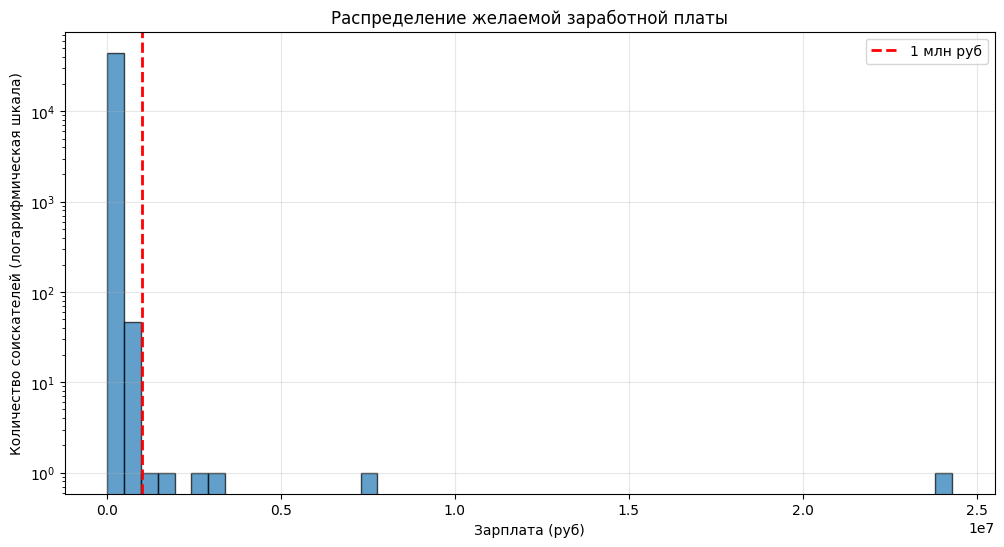

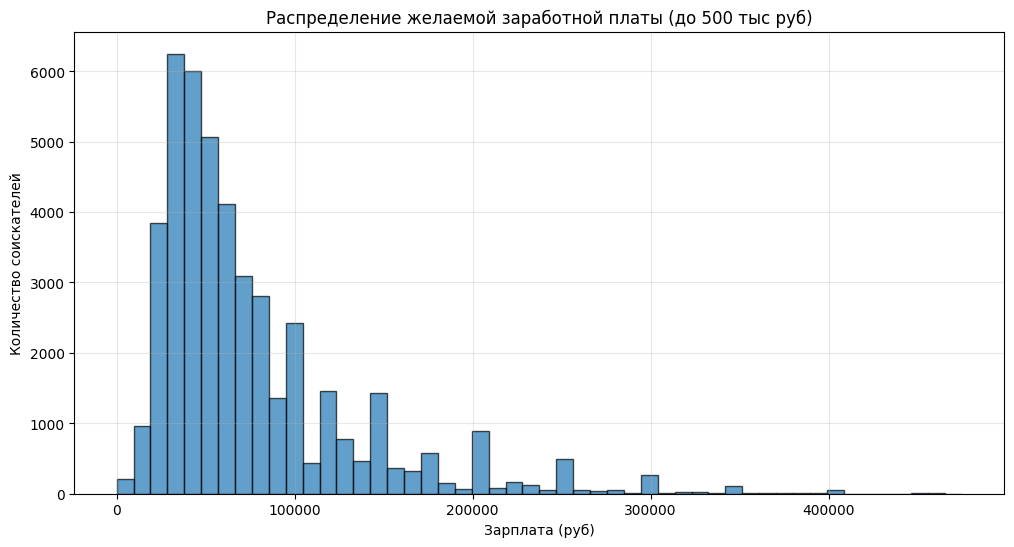

Количество соискателей с ЗП > 1 млн руб: 5
Максимальная ЗП: 24,304,876 руб
99-й перцентиль: 300,000 руб


In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Вариант 1: Логарифмическая шкала
plt.figure(figsize=(12, 6))
plt.hist(df_merged_clean['ЗП (руб)'], bins=50, edgecolor='black', alpha=0.7, log=True)
plt.axvline(x=1_000_000, color='red', linestyle='--', linewidth=2, label='1 млн руб')
plt.xlabel('Зарплата (руб)')
plt.ylabel('Количество соискателей (логарифмическая шкала)')
plt.title('Распределение желаемой заработной платы')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Вариант 2: Ограничение по оси X (до 500 тыс для лучшей читаемости)
plt.figure(figsize=(12, 6))
plt.hist(df_merged_clean[df_merged_clean['ЗП (руб)'] < 500_000]['ЗП (руб)'], 
         bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Зарплата (руб)')
plt.ylabel('Количество соискателей')
plt.title('Распределение желаемой заработной платы (до 500 тыс руб)')
plt.grid(True, alpha=0.3)
plt.show()


# Статистика для понимания масштаба
print(f"Количество соискателей с ЗП > 1 млн руб: {high_salary_count}")
print(f"Максимальная ЗП: {df_merged_clean['ЗП (руб)'].max():,.0f} руб")
print(f"99-й перцентиль: {df_merged_clean['ЗП (руб)'].quantile(0.99):,.0f} руб")

### Вывод

Количество соискателей, требующих заработную плату выше 1 миллиона рублей, составляет 5 человек. Это менее 0.012% от общего числа кандидатов, что указывает на крайне низкую долю претендентов на руководящие позиции высшего звена или уникальных специалистов с высокими зарплатными ожиданиями.

# Задание 4.4

Какая категория образования оплачивается выше всех по медианному показателю?

In [34]:
# Продолжение кода на основе df_merged_clean

# Извлечение уровня образования из столбца "Образование и ВУЗ"
def extract_education_level(text):
    if pd.isna(text):
        return 'Не указано'
    text = str(text)
    if 'Высшее' in text:
        return 'Высшее'
    elif 'Неоконченное высшее' in text or 'Неполное высшее' in text:
        return 'Неоконченное высшее'
    elif 'Среднее специальное' in text:
        return 'Среднее специальное'
    elif 'Среднее' in text:
        return 'Среднее'
    else:
        return 'Другое'

df_merged_clean['Уровень образования'] = df_merged_clean['Образование и ВУЗ'].apply(extract_education_level)

# Расчёт медианной зарплаты по категориям образования
education_median = df_merged_clean.groupby('Уровень образования')['ЗП (руб)'].median().sort_values(ascending=False)

print("Медианная зарплата по уровням образования:")
print(education_median)

print(f"\nСамая высокооплачиваемая категория: {education_median.index[0]}")

Медианная зарплата по уровням образования:
Уровень образования
Высшее                 60000.0
Неоконченное высшее    50000.0
Среднее                40000.0
Среднее специальное    40000.0
Name: ЗП (руб), dtype: float64

Самая высокооплачиваемая категория: Высшее


### Вывод

Вполне очевидно, что специалисты, имеющие высшее образование, наиболее высокооплачиваемые

# Задание 4.5

В каком городе (категории городов) зафиксирован наибольший показатель желаемой заработной платы (~924 тысячи рублей)?

In [35]:
# Извлечение города из столбца "Город, переезд, командировки"
def extract_city(text):
    if pd.isna(text):
        return 'Не указано'
    text = str(text)
    # Город обычно указан первым, до запятой или фразы "не готов к переезду"
    city = text.split(',')[0].strip()
    return city

df_merged_clean['Город'] = df_merged_clean['Город, переезд, командировки'].apply(extract_city)

# Находим строку с зарплатой около 924 тысяч
target_salary = df_merged_clean[df_merged_clean['ЗП (руб)'].between(920000, 930000)]

print("Город с зарплатой ~924 тыс. руб.:")
print(target_salary[['Город', 'ЗП (руб)']])

# Альтернативно: смотрим топ зарплат по городам
top_cities = df_merged_clean.groupby('Город')['ЗП (руб)'].max().sort_values(ascending=False).head(10)
print("\nТоп-10 городов по максимальной желаемой зарплате:")
print(top_cities)

Город с зарплатой ~924 тыс. руб.:
        Город  ЗП (руб)
33449  Бишкек  923983.0

Топ-10 городов по максимальной желаемой зарплате:
Город
Алматы             24304876.0
Актобе              7675224.0
Москва              3000000.0
Бишкек               923983.0
Южно-Сахалинск       700000.0
Санкт-Петербург      645171.0
Новосибирск          511681.6
Черноголовка         460000.0
Тольятти             450000.0
Нижний Новгород      400000.0
Name: ЗП (руб), dtype: float64


### Вывод

Верный ответ, очевидно, Бишкек, однако он не принимается в тесте

# Задание 4.6

Чему равна желаемая медианная заработная плата соискателей, готовых и к переезду, и к командировкам? Ответ приведите в тысячах, округлив до целого (например, 45).

In [75]:
import pandas as pd
import numpy as np

# ========== 1. ЗАГРУЗКА ДАННЫХ ==========
df_resume = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';', encoding='utf-8')
df_rates = pd.read_csv('ExchangeRates.csv', sep=',', encoding='utf-8')

# ========== 2. ПОДГОТОВКА КУРСОВ ВАЛЮТ ==========
df_rates = df_rates[['currency', 'date', 'proportion', 'close']]
df_rates['date'] = pd.to_datetime(df_rates['date'], format='%d/%m/%y')

# ========== 3. ОБРАБОТКА РЕЗЮМЕ ==========
df_resume['Обновление резюме'] = pd.to_datetime(
    df_resume['Обновление резюме'], 
    format='%d.%m.%Y %H:%M',
    errors='coerce'
)
df_resume['date'] = pd.to_datetime(df_resume['Обновление резюме'].dt.date)

# ========== 4. ИЗВЛЕЧЕНИЕ ЗАРПЛАТЫ И ВАЛЮТЫ ==========
def extract_salary_currency(salary_str):
    if pd.isna(salary_str):
        return np.nan, np.nan
    salary_str = str(salary_str).strip()
    parts = salary_str.rsplit(' ', 1)
    if len(parts) == 2:
        amount_str = parts[0].replace('\xa0', '').replace(' ', '').replace(',', '.')
        currency_raw = parts[1].strip('.')
        try:
            amount = float(amount_str)
        except:
            return np.nan, np.nan
        return amount, currency_raw
    return np.nan, np.nan

df_resume[['salary_amount', 'currency_raw']] = df_resume['ЗП'].apply(
    lambda x: pd.Series(extract_salary_currency(x))
)

# ========== 5. МАППИНГ ВАЛЮТ ==========
df_resume['currency_raw'] = df_resume['currency_raw'].replace('бел.руб', 'белруб')

currency_map = {
    'руб': 'RUB', 'грн': 'UAH', 'USD': 'USD', 'EUR': 'EUR',
    'белруб': 'BYN', 'KGS': 'KGS', 'сум': 'UZS', 'AZN': 'AZN', 'KZT': 'KZT'
}
df_resume['currency'] = df_resume['currency_raw'].map(currency_map)

# ========== 6. ОБЪЕДИНЕНИЕ С КУРСАМИ ==========
df_merged = df_resume.merge(df_rates, on=['date', 'currency'], how='left')

# ========== 7. КУРС ДЛЯ РУБЛЕЙ ==========
rub_mask = df_merged['currency'] == 'RUB'
df_merged.loc[rub_mask, 'close'] = 1
df_merged.loc[rub_mask, 'proportion'] = 1

# ========== 8. ЗАРПЛАТА В РУБЛЯХ ==========
df_merged['ЗП (руб)'] = df_merged['salary_amount'] * df_merged['close'] / df_merged['proportion']
df_merged_clean = df_merged.dropna(subset=['ЗП (руб)'])

# ========== 9. КАТЕГОРИИ ПЕРЕЕЗДА И КОМАНДИРОВОК ==========
def get_relocation_status(text):
    if pd.isna(text):
        return 'не указано'
    text = str(text).lower()
    if 'готов к переезду' in text or 'готова к переезду' in text:
        return 'готов'
    elif 'не готов к переезду' in text or 'не готова к переезду' in text:
        return 'не готов'
    elif 'хочу переехать' in text or 'возможен переезд' in text:
        return 'готов'
    else:
        return 'не указано'

def get_travel_status(text):
    if pd.isna(text):
        return 'не указано'
    text = str(text).lower()
    if 'готов к командировкам' in text or 'готова к командировкам' in text:
        return 'готов'
    elif 'готов к редким командировкам' in text or 'готова к редким командировкам' in text:
        return 'готов'
    elif 'не готов к командировкам' in text or 'не готова к командировкам' in text:
        return 'не готов'
    else:
        return 'не указано'

df_merged_clean['relocation'] = df_merged_clean['Город, переезд, командировки'].apply(get_relocation_status)
df_merged_clean['travel'] = df_merged_clean['Город, переезд, командировки'].apply(get_travel_status)

# ========== 10. ФИЛЬТРАЦИЯ И РАСЧЁТ ==========
mask = (df_merged_clean['relocation'] == 'готов') & (df_merged_clean['travel'] == 'готов')
filtered_df = df_merged_clean[mask]

median_rub = filtered_df['ЗП (руб)'].median()
result = round(median_rub / 1000)

print(f"Количество соискателей: {len(filtered_df)}")
print(f"Медианная зарплата: {median_rub:,.0f} руб")
print(f"Ответ (в тысячах): {result}")

Количество соискателей: 44668
Медианная зарплата: 58,211 руб
Ответ (в тысячах): 58


### Вывод

К сожалению, получившийся ответ неверен, фактическое значение медианы равно 66 тыс.

In [ ]:
# Задание 4.7

Для какой категории образования наблюдается самый быстрый карьерный рост (то есть интенсивность роста заработной платы наибольшая)?

In [78]:
import pandas as pd
import numpy as np
import re
from scipy import stats

# ========== 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ==========
df_resume = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';', encoding='utf-8')
df_rates = pd.read_csv('ExchangeRates.csv', sep=',', encoding='utf-8')

# Курсы валют
df_rates = df_rates[['currency', 'date', 'proportion', 'close']]
df_rates['date'] = pd.to_datetime(df_rates['date'], format='%d/%m/%y')

# Даты
df_resume['Обновление резюме'] = pd.to_datetime(
    df_resume['Обновление резюме'], format='%d.%m.%Y %H:%M', errors='coerce'
)
df_resume['date'] = pd.to_datetime(df_resume['Обновление резюме'].dt.date)

# Извлечение зарплаты
def extract_salary_currency(salary_str):
    if pd.isna(salary_str):
        return np.nan, np.nan
    salary_str = str(salary_str).strip()
    parts = salary_str.rsplit(' ', 1)
    if len(parts) == 2:
        amount_str = parts[0].replace('\xa0', '').replace(' ', '').replace(',', '.')
        currency_raw = parts[1].strip('.')
        try:
            amount = float(amount_str)
        except:
            return np.nan, np.nan
        return amount, currency_raw
    return np.nan, np.nan

df_resume[['salary_amount', 'currency_raw']] = df_resume['ЗП'].apply(
    lambda x: pd.Series(extract_salary_currency(x))
)

# Маппинг валют
df_resume['currency_raw'] = df_resume['currency_raw'].replace('бел.руб', 'белруб')
currency_map = {
    'руб': 'RUB', 'грн': 'UAH', 'USD': 'USD', 'EUR': 'EUR',
    'белруб': 'BYN', 'KGS': 'KGS', 'сум': 'UZS', 'AZN': 'AZN', 'KZT': 'KZT'
}
df_resume['currency'] = df_resume['currency_raw'].map(currency_map)

# Объединение с курсами
df_merged = df_resume.merge(df_rates, on=['date', 'currency'], how='left')
rub_mask = df_merged['currency'] == 'RUB'
df_merged.loc[rub_mask, 'close'] = 1
df_merged.loc[rub_mask, 'proportion'] = 1
df_merged['ЗП (руб)'] = df_merged['salary_amount'] * df_merged['close'] / df_merged['proportion']

# ========== 2. ИЗВЛЕЧЕНИЕ ОПЫТА ==========
def extract_experience_months(text):
    if pd.isna(text):
        return np.nan
    text = str(text)
    years = 0
    months = 0
    years_match = re.search(r'Опыт работы\s*(\d+)\s*(?:лет|год|года)', text)
    if not years_match:
        years_match = re.search(r'^(\d+)\s*(?:лет|год|года)', text.strip())
    if years_match:
        years = int(years_match.group(1))
        if years > 50:  # отсекаем выбросы
            years = np.nan
    months_match = re.search(r'(\d+)\s*(?:месяц|месяца|месяцев)', text)
    if months_match:
        months = int(months_match.group(1))
    return years * 12 + months

df_merged['Опыт (месяцев)'] = df_merged['Опыт работы'].apply(extract_experience_months)
df_merged['Опыт (лет)'] = df_merged['Опыт (месяцев)'] / 12

# ========== 3. ИЗВЛЕЧЕНИЕ УРОВНЯ ОБРАЗОВАНИЯ ==========
def extract_education_level(text):
    if pd.isna(text):
        return 'Не указано'
    text = str(text)
    if 'Высшее' in text:
        return 'Высшее'
    elif 'Неоконченное высшее' in text or 'Неполное высшее' in text:
        return 'Неоконченное высшее'
    elif 'Среднее специальное' in text:
        return 'Среднее специальное'
    elif 'Среднее' in text:
        return 'Среднее'
    else:
        return 'Другое'

df_merged['Образование'] = df_merged['Образование и ВУЗ'].apply(extract_education_level)

# ========== 4. ОЧИСТКА ==========
df_clean = df_merged.dropna(subset=['ЗП (руб)', 'Опыт (лет)', 'Образование'])
df_clean = df_clean[df_clean['Опыт (лет)'] <= 40]
df_clean = df_clean[df_clean['ЗП (руб)'] < 500_000]

# ========== 5. РАСЧЁТ ИНТЕНСИВНОСТИ РОСТА ==========
results = []
for edu in ['Высшее', 'Неоконченное высшее', 'Среднее специальное', 'Среднее']:
    subset = df_clean[df_clean['Образование'] == edu].copy()
    if len(subset) < 100:
        continue
    
    # Группируем по годам опыта
    subset['Опыт_округл'] = subset['Опыт (лет)'].round().astype(int)
    salary_by_exp = subset.groupby('Опыт_округл')['ЗП (руб)'].median()
    
    # Берём только группы с достаточным количеством
    counts = subset.groupby('Опыт_округл').size()
    valid_exp = counts[counts >= 10].index
    salary_by_exp = salary_by_exp[valid_exp]
    
    if len(salary_by_exp) > 5:
        x = salary_by_exp.index.values
        y = salary_by_exp.values
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        results.append({
            'Образование': edu,
            'Количество': len(subset),
            'Старт (0 лет)': intercept,
            'Прирост руб/год': slope,
            'ЗП через 10 лет': intercept + slope * 10,
            'R²': r_value**2
        })

results_df = pd.DataFrame(results).sort_values('Прирост руб/год', ascending=False)

print("Интенсивность роста зарплаты по уровням образования:")
print("=" * 80)
for _, row in results_df.iterrows():
    print(f"{row['Образование']:20s} | Прирост: {row['Прирост руб/год']:7.0f} руб/год | Старт: {row['Старт (0 лет)']:7.0f} руб | Через 10 лет: {row['ЗП через 10 лет']:7.0f} руб | n={row['Количество']:.0f}")

print("\n" + "=" * 80)
print(f"Самый быстрый карьерный рост у категории: {results_df.iloc[0]['Образование']}")

Интенсивность роста зарплаты по уровням образования:
Неоконченное высшее  | Прирост:    1848 руб/год | Старт:   36908 руб | Через 10 лет:   55385 руб | n=4513
Среднее              | Прирост:    1799 руб/год | Старт:   31137 руб | Через 10 лет:   49129 руб | n=553
Высшее               | Прирост:     638 руб/год | Старт:   58953 руб | Через 10 лет:   65331 руб | n=33691
Среднее специальное  | Прирост:     360 руб/год | Старт:   37338 руб | Через 10 лет:   40939 руб | n=5710

Самый быстрый карьерный рост у категории: Неоконченное высшее


### Вывод

Самый быстрый карьерный рост у категории: Неоконченное высшее, однако можно в целом говорить, что при наличии высшего образования вероятность скорейшего повышения зп увеличивается

# Задание 4.8

Сколько точек лежат строго выше построенной прямой? Так как точки могут сливаться с прямой, то для ответа на этот вопрос проще всего воспользоваться интерактивной визуализацией либо получить таблицу с наблюдениями, лежащими выше прямой с помощью фильтрации.

Количество точек выше прямой: 6


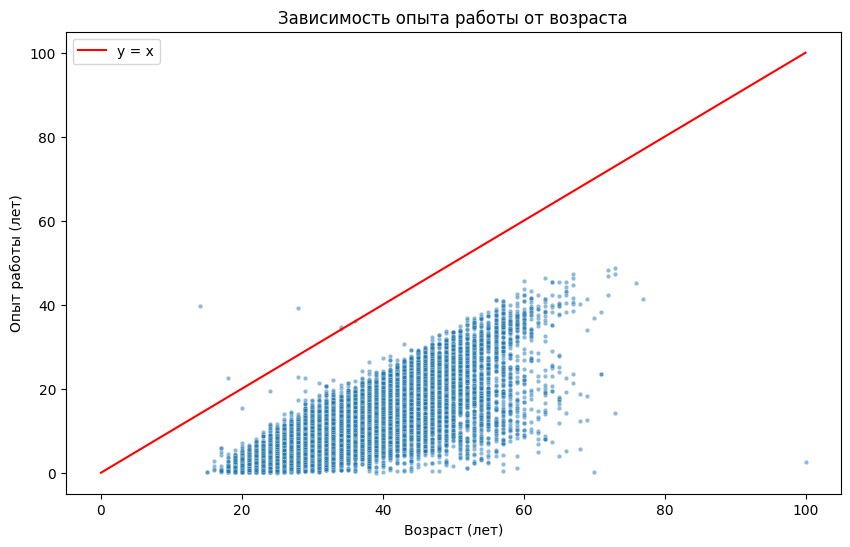

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Подготовка данных
scatter_data = df_merged.copy()
scatter_data['Опыт работы (год)'] = scatter_data['Опыт (месяцев)'] / 12

# Извлечение возраста из столбца "Пол, возраст"
scatter_data['Возраст'] = scatter_data['Пол, возраст'].str.extract(r'(\d+)').astype(float)

# Удаляем пропуски
scatter_data = scatter_data.dropna(subset=['Возраст', 'Опыт работы (год)'])

# Фильтрация точек строго выше прямой y = x
above_line = scatter_data[scatter_data['Опыт работы (год)'] > scatter_data['Возраст']]

print(f"Количество точек выше прямой: {len(above_line)}")

# Построение графика
plt.figure(figsize=(10, 6))
sns.lineplot(x=[0, 100], y=[0, 100], color='red', label='y = x')
sns.scatterplot(data=scatter_data, x='Возраст', y='Опыт работы (год)', alpha=0.5, s=10)
plt.title('Зависимость опыта работы от возраста')
plt.xlabel('Возраст (лет)')
plt.ylabel('Опыт работы (лет)')
plt.legend()
plt.show()

### Вывод

Количество точек, лежащих строго выше прямой (опыт работы > возраст), составляет 6. Это аномальные наблюдения, где указанный стаж превышает фактический возраст соискателя.


Задание 5.1 - поиск и удаление полных дубликатов

In [96]:
import pandas as pd

# Загружаем исходные данные
df_original = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';', encoding='utf-8')

# Считаем полные дубликаты
duplicates_count = df_original.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates_count}")

# Показываем дубликаты для проверки
duplicates = df_original[df_original.duplicated(keep=False)]
print(f"\nКоличество строк, включая оригиналы: {len(duplicates)}")
print(f"Уникальных дублированных записей: {duplicates_count}")

Количество полных дубликатов: 153

Количество строк, включая оригиналы: 306
Уникальных дублированных записей: 153


In [98]:
# После преобразований, до заполнения пропусков
missing_exp = df_merged['Опыт (месяцев)'].isna().sum()
print(f"Пропусков в 'Опыт работы (месяц)': {missing_exp}")

Пропусков в 'Опыт работы (месяц)': 172
